# Ocena 3.0

Przeprowadzamy analizę kąta torsyjnego $\chi$ w wiązaniu glikozydowym. Celem jest zbadanie rozkładu wartości kątów oraz wyznaczenie statystyk opisowych dla dwóch głównych konformacji: anti oraz syn.

## Import bibliotek i definicja funkcji statystycznych
Poniższy kod importuje niezbędne biblioteki do analizy danych i tworzenia wykresów.Definiujemy tu również dwie kluczowe funkcje, ponieważ pracujemy z danymi cyklicznymi (kątami), gdzie $0^\circ$ i $360^\circ$ są tożsame:
* circular_median: Oblicza medianę, uwzględniając cykliczność danych (standardowa mediana byłaby błędna w okolicach przejścia $360^\circ/0^\circ$).
* get_ci: Funkcja wykorzystująca metodę bootstrap (losowanie ze zwracaniem) do oszacowania 95% przedziału ufności dla zadanej funkcji statystycznej.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import circmean
from sklearn.utils import resample

def circular_median(angles_rad):
    mean_ang = circmean(angles_rad)
    centered_angles = np.angle(np.exp(1j * (angles_rad - mean_ang)))
    med_centered = np.median(centered_angles)
    return mean_ang + med_centered

def get_ci(data_rad, func, n_boot=1000, ci=0.95):
    stats = []
    for _ in range(n_boot):
        sample = resample(data_rad)
        stats.append(func(sample))
    
    p_lower = ((1.0 - ci) / 2.0) * 100
    p_upper = (ci + ((1.0 - ci) / 2.0)) * 100
    
    lower = np.percentile(stats, p_lower)
    upper = np.percentile(stats, p_upper)
    
    return lower, upper

## Wczytanie i przygotowanie danych
Wczytujemy plik chi.csv. Na podstawie próbki danych widzimy, że:
1. Kolumna z wartościami kątów nazywa się `chi` i zawiera dane w radianach (zakres ok. $-\pi$ do $\pi$).
2. Kolumna klasyfikująca nazywa się `glyco_bond`.

Dlatego tworzymy pomocniczą kolumnę deg (stopnie) tylko do celów wizualizacji, natomiast obliczenia statystyczne wykonujemy na oryginalnych danych w radianach.

In [2]:
FILENAME = 'chi.csv'
COL_ANGLE = 'chi'         # Wartości w radianach
COL_CLASS = 'glyco_bond'  # Klasyfikacja (syn/anti)

df = pd.read_csv(FILENAME)

df['rad'] = df[COL_ANGLE]

# Do wizualizacji (wykresów) przeliczamy na stopnie
df['deg'] = np.deg2rad(df[COL_ANGLE]) if df[COL_ANGLE].max() > 10 else np.rad2deg(df[COL_ANGLE])

data_anti = df[df[COL_CLASS] == 'anti']
data_syn = df[df[COL_CLASS] == 'syn']

print("Podgląd wczytanych danych:")
print(df.head())

Podgląd wczytanych danych:
        chi glyco_bond       rad      deg
0 -3.140964       anti -3.140964 -179.964
1 -2.772770       anti -2.772770 -158.868
2 -2.854661       anti -2.854661 -163.560
3 -2.795913       anti -2.795913 -160.194
4  1.030565        syn  1.030565   59.047


## Wizualizacja danych (Histogramy)
Generujemy histogramy w zakresie od $-180^\circ$ do $180^\circ$, co odpowiada zakresowi $-\pi$ do $\pi$ radianów.

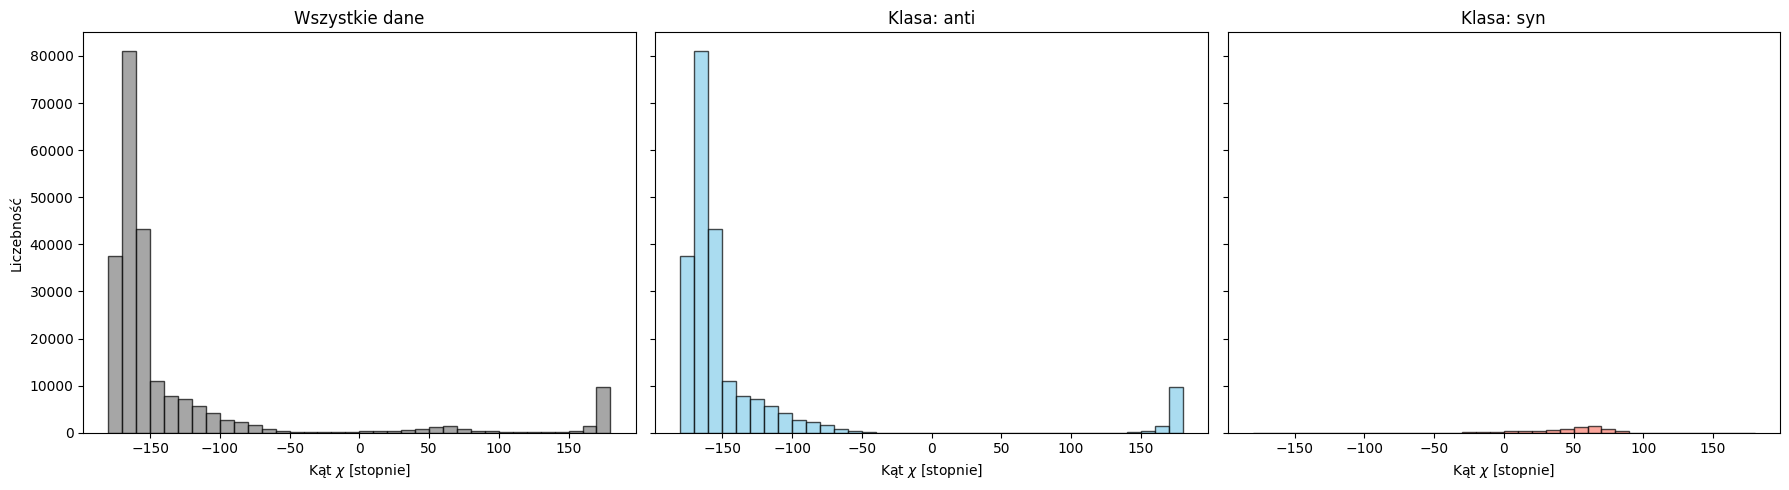

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Ustawiamy zakres osi X od -180 do 180 stopni
bins = np.linspace(-180, 180, 37) 

# A. Wszystkie dane
axes[0].hist(df['deg'], bins=bins, color='gray', edgecolor='black', alpha=0.7)
axes[0].set_title('Wszystkie dane')
axes[0].set_xlabel(r'Kąt $\chi$ [stopnie]')
axes[0].set_ylabel('Liczebność')

# B. Klasa ANTI
axes[1].hist(data_anti['deg'], bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Klasa: anti')
axes[1].set_xlabel(r'Kąt $\chi$ [stopnie]')

# C. Klasa SYN
axes[2].hist(data_syn['deg'], bins=bins, color='salmon', edgecolor='black', alpha=0.7)
axes[2].set_title('Klasa: syn')
axes[2].set_xlabel(r'Kąt $\chi$ [stopnie]')

plt.tight_layout()
plt.show()

## Wizualizacja kołowa

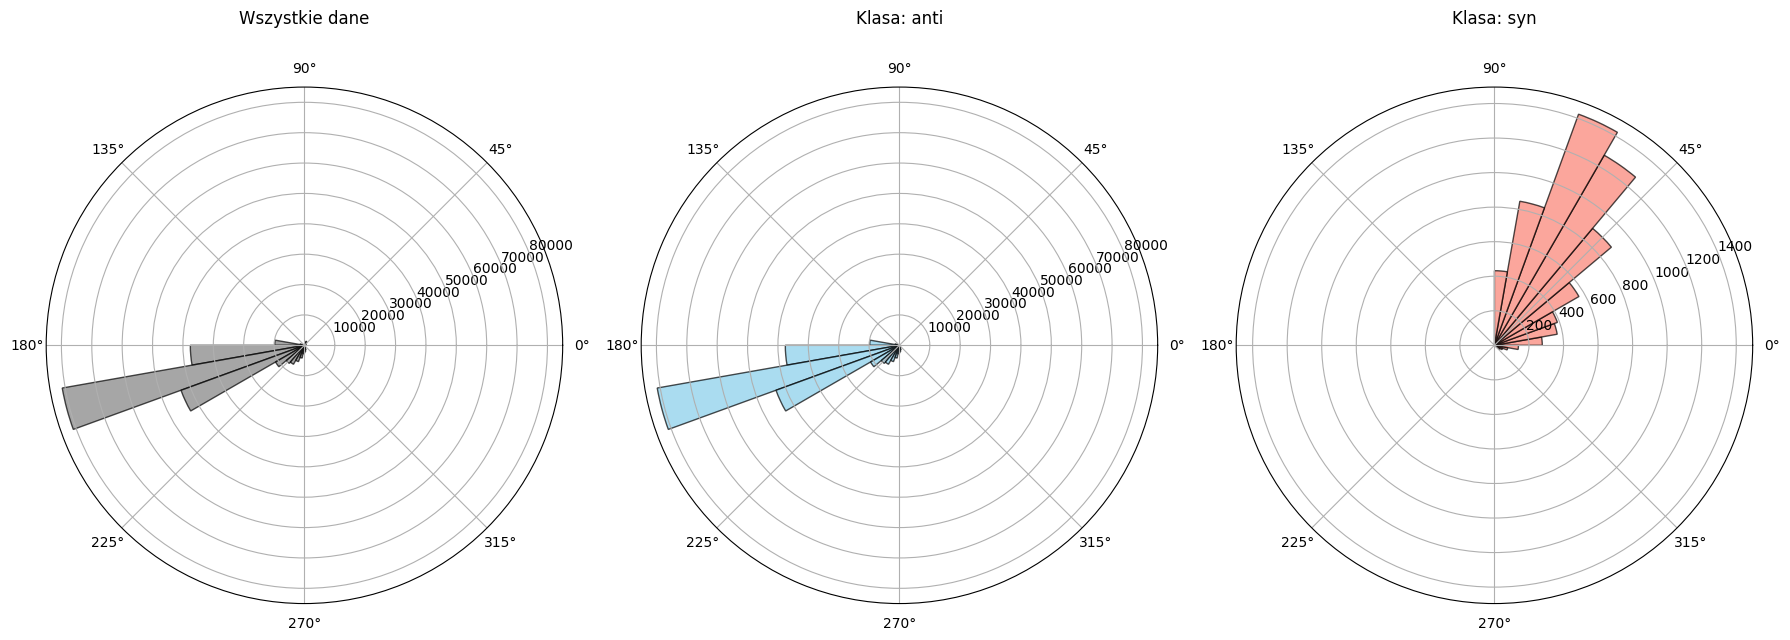

In [4]:
# Ustawienia wykresu - 3 panele, rzutowanie biegunowe (polar)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': 'polar'})

n_bins = 36  # Podział koła na 36 części (co 10 stopni)
bins = np.linspace(-np.pi, np.pi, n_bins + 1)
width = 2 * np.pi / n_bins  # Szerokość jednego słupka w radianach

def plot_rose(ax, data, color, title):
    # Obliczenie liczebności w każdym przedziale kątowym
    counts, _ = np.histogram(data, bins=bins)
    
    # Wyznaczenie środków binów do rysowania słupków
    theta = bins[:-1] + width / 2
    
    # Rysowanie słupków
    ax.bar(theta, counts, width=width, bottom=0.0, color=color, edgecolor='black', alpha=0.7)
    
    # Ustawienia tytułu
    ax.set_title(title, va='bottom', y=1.1)

# 1. Wszystkie dane
plot_rose(axes[0], df['rad'], 'gray', 'Wszystkie dane')

# 2. Klasa anti
plot_rose(axes[1], data_anti['rad'], 'skyblue', 'Klasa: anti')

# 3. Klasa syn
plot_rose(axes[2], data_syn['rad'], 'salmon', 'Klasa: syn')

plt.tight_layout()
plt.show()

## Obliczenia statystyczne
Wyznaczamy średnią i medianę kołową. Funkcja circmean domyślnie zakłada zakres $[0, 2\pi]$. Ponieważ nasze dane są w zakresie $[-\pi, \pi]$, musimy to jawnie wskazać (`low=-np.pi, high=np.pi`), aby statystyka była poprawna.

In [5]:
print(f"{'Klasa':<10} | {'Statystyka':<10} | {'Wartość':<10} | {'95% CI (dolny - górny)'}")
print("-" * 65)

# Funkcja pomocnicza do formatowania (zostawia zakres -180 do 180)
def to_deg_fmt(rad):
    d = np.rad2deg(rad)
    # Normalizacja do -180..180
    d = (d + 180) % 360 - 180
    return d

for label, subset in [('anti', data_anti), ('syn', data_syn)]:
    if len(subset) == 0:
        print(f"Brak danych dla klasy {label}")
        continue
        
    data_rad = subset['rad'].values
    
    # 1. Średnia kołowa
    theta_mean = circmean(data_rad, low=-np.pi, high=np.pi)
    
    # Do bootstrapu musimy przekazać funkcję z ustalonymi parametrami low/high
    calc_mean_pi = lambda x: circmean(x, low=-np.pi, high=np.pi)
    ci_mean_low, ci_mean_high = get_ci(data_rad, calc_mean_pi)
    
    # 2. Mediana kołowa
    theta_med = circular_median(data_rad)
    ci_med_low, ci_med_high = get_ci(data_rad, circular_median)
    
    print(f"{label:<10} | Średnia    | {to_deg_fmt(theta_mean):6.2f}°    | [{to_deg_fmt(ci_mean_low):6.2f}°, {to_deg_fmt(ci_mean_high):6.2f}°]")
    print(f"{label:<10} | Mediana    | {to_deg_fmt(theta_med):6.2f}°    | [{to_deg_fmt(ci_med_low):6.2f}°, {to_deg_fmt(ci_med_high):6.2f}°]")
    print("-" * 65)

Klasa      | Statystyka | Wartość    | 95% CI (dolny - górny)
-----------------------------------------------------------------
anti       | Średnia    | -157.96°    | [-158.05°, -157.88°]
anti       | Mediana    | -162.45°    | [-162.51°, -162.40°]
-----------------------------------------------------------------
syn        | Średnia    |  50.30°    | [ 49.71°,  50.89°]
syn        | Mediana    |  54.90°    | [ 54.35°,  55.67°]
-----------------------------------------------------------------


# Ocena 3.5

## Definicja funkcji odległości

Na początku importujemy funkcję do testu Wilcoxona oraz definiujemy funkcję obliczającą odległość na okręgu. Funkcja ta realizuje wzór $d(\alpha, \beta) = ((\alpha - \beta + \pi) \pmod{2\pi}) - \pi$, zwracając wynik w przedziale $(-\pi, \pi]$.

In [6]:
from scipy.stats import wilcoxon

def circular_distance(alpha, beta):
    return ((alpha - beta + np.pi) % (2 * np.pi)) - np.pi

## Obliczenie odchyleń od mediany ($x_i$)

Dla obu klas (anti i syn) wyznaczamy medianę kołową, a następnie obliczamy wektor odchyleń $x_i$ dla każdego punktu pomiarowego względem tej mediany. Te wartości posłużą nam zarówno do testu statystycznego, jak i do wizualizacji.

In [7]:
rad_anti = data_anti['rad'].values
med_anti = circular_median(rad_anti)
xi_anti = circular_distance(rad_anti, med_anti)

rad_syn = data_syn['rad'].values
med_syn = circular_median(rad_syn)
xi_syn = circular_distance(rad_syn, med_syn)

## Test Wilcoxona dla par wiązanych

Wykonujemy test Wilcoxona (signed-rank test) na obliczonych odchyleniach. Weryfikujemy hipotezę zerową, że rozkład odchyleń jest symetryczny względem zera. Wyświetlamy statystykę testu, wartość p (p-value) oraz interpretację wyniku przy poziomie istotności $\alpha=0.05$.

In [8]:
stat_anti, p_anti = wilcoxon(xi_anti)
stat_syn, p_syn = wilcoxon(xi_syn)

print(f"{'Klasa':<10} | {'Statystyka':<10} | {'P-value':<10} | {'Wniosek'}")
print("-" * 55)

res_anti = "Symetryczny" if p_anti > 0.05 else "Asymetryczny"
res_syn = "Symetryczny" if p_syn > 0.05 else "Asymetryczny"

print(f"{'anti':<10} | {stat_anti:10.1f} | {p_anti:.4f}     | {res_anti}")
print(f"{'syn':<10} | {stat_syn:10.1f} | {p_syn:.4f}     | {res_syn}")

Klasa      | Statystyka | P-value    | Wniosek
-------------------------------------------------------
anti       | 10780901416.5 | 0.0000     | Asymetryczny
syn        | 10023400.5 | 0.0000     | Asymetryczny


## Wizualna ocena symetrii

Tworzymy histogramy rozkładu odchyleń $x_i$. Oś X została przeliczona na stopnie dla łatwiejszej interpretacji. Czerwona przerywana linia oznacza zero (medianę).

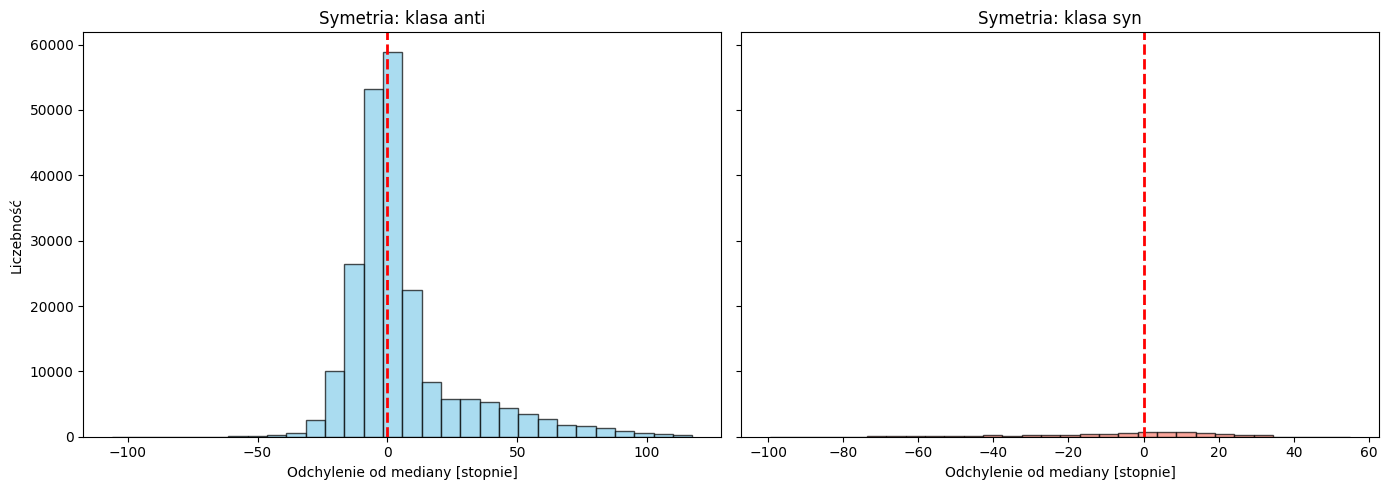

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

xi_anti_deg = np.rad2deg(xi_anti)
xi_syn_deg = np.rad2deg(xi_syn)

axes[0].hist(xi_anti_deg, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title(r'Symetria: klasa anti')
axes[0].set_xlabel(r'Odchylenie od mediany [stopnie]')
axes[0].set_ylabel('Liczebność')

axes[1].hist(xi_syn_deg, bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title(r'Symetria: klasa syn')
axes[1].set_xlabel(r'Odchylenie od mediany [stopnie]')

plt.tight_layout()
plt.show()

## Analiza
* Brak symetrii statystycznej: Dla obu klas (anti i syn) test Wilcoxona wykazał wartość $p \approx 0$ (znacznie poniżej poziomu istotności $\alpha=0.05$). Oznacza to odrzucenie hipotezy zerowej – rozkłady kątów nie są symetryczne względem swoich median.
* Kierunek asymetrii: Wizualizacja (histogram dla klasy anti) ujawnia wyraźną skośność prawostronną. Wykres posiada dłuższy "ogon" dla dodatnich odchyleń od mediany, co oznacza, że wiązanie łatwiej wychyla się w kierunku dodatnim.
* Interpretacja: Obserwowana asymetria świadczy o asymetrii profilu energetycznego (niesymetrycznym kształcie potencjału). Rotacja wiązania w jedną stronę napotyka na "sztywną" barierę steryczną (szybki wzrost energii), podczas gdy w przeciwnym kierunku bariera narasta łagodniej, pozwalając na większą swobodę ruchu.

# Ocena 4.0

## Centrowanie danych kołowych
Pierwszym krokiem jest przesunięcie danych tak, aby ich średnia kołowa znajdowała się w punkcie 0. Jest to niezbędne do poprawnego porównania kształtu rozkładu z rozkładem teoretycznym na wykresie Q-Q. Definiujemy funkcję, która oblicza średnią kołową, a następnie odejmuje ją od każdego punktu pomiarowego, normalizując wynik do zakresu $(-\pi, \pi]$. Następnie stosujemy tę funkcję do obu zbiorów danych (anti i syn).

In [10]:
def center_circular_data(data_rad):
    mu = circmean(data_rad, low=-np.pi, high=np.pi)
    centered = np.angle(np.exp(1j * (data_rad - mu)))
    return centered

centered_anti = center_circular_data(data_anti['rad'].values)
centered_syn = center_circular_data(data_syn['rad'].values)

## Wizualizacja: Wykres Q-Q (Quantile-Quantile)
Tworzymy wykres Q-Q, aby porównać rozkład naszych scentrowanych danych z rozkładem jednostajnym.
* Oś X (Teoretyczna): Kwantyle rozkładu jednostajnego na okręgu. Dla $n$ punktów są to wartości równomiernie rozłożone od $-\pi$ do $\pi$.
* Oś Y (Empiryczna): Posortowane wartości z naszego zbioru danych.
* Linia odniesienia: Czerwona przerywana linia $y=x$.

Jeśli punkty układają się wzdłuż czerwonej linii, rozkład jest jednostajny. Kształt litery "S" lub silne odchylenia świadczą o skoncentrowaniu danych wokół średniej (czyli o istnieniu preferowanej konformacji).

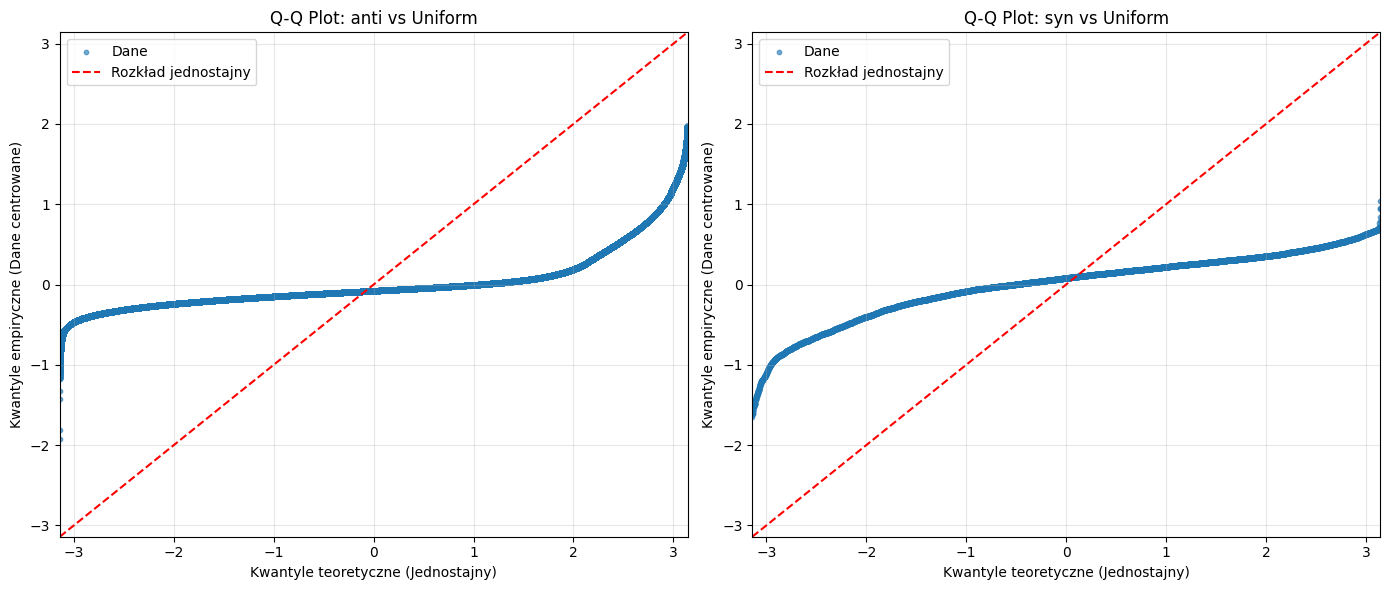

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (label, centered_data) in enumerate([('anti', centered_anti), ('syn', centered_syn)]):
    if len(centered_data) == 0: continue
        
    sorted_data = np.sort(centered_data)
    n = len(sorted_data)
    
    percentiles = (np.arange(1, n + 1) - 0.5) / n
    theoretical_quantiles = percentiles * 2 * np.pi - np.pi
    
    ax = axes[i]
    ax.scatter(theoretical_quantiles, sorted_data, s=10, alpha=0.6, label='Dane')
    ax.plot([-np.pi, np.pi], [-np.pi, np.pi], color='red', linestyle='--', label='Rozkład jednostajny')
    
    ax.set_title(f'Q-Q Plot: {label} vs Uniform')
    ax.set_xlabel('Kwantyle teoretyczne (Jednostajny)')
    ax.set_ylabel('Kwantyle empiryczne (Dane centrowane)')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Wnioski z analizy Q-Q plot:
* Odchylenie od modelu: Na obu wykresach punkty drastycznie odbiegają od czerwonej linii referencyjnej ($y=x$), układając się w kształt litery "S". Świadczy to o braku zgodności z rozkładem jednostajnym.
* Koncentracja danych: Płaski przebieg krzywej w środkowej części wykresu oznacza, że zmienność danych rzeczywistych (oś Y) jest znacznie mniejsza niż teoretyczna (oś X). Dane są silnie skupione wokół średniej.
* Potwierdzenie testów: Wizualizacja jest spójna z wynikami testów Kuipera i Rayleigha – odrzucamy hipotezę o jednostajnym rozkładzie kątów. Wiązania nie rotują losowo, lecz przyjmują preferowane konformacje.

## Definicja testu Rayleigha
Definiujemy funkcję wykonującą test Rayleigha. Służy on do weryfikacji hipotezy o jednostajności rozkładu na okręgu. Test ten jest szczególnie mocny w wykrywaniu rozkładów jednomodalnych (skupionych w jednym kierunku).Funkcja oblicza długość wektora wypadkowego ($\bar{R}$), statystykę $z$ oraz wartość $p$ przy użyciu przybliżenia dla dużych prób.

In [12]:
def rayleigh_test_uniform(data_rad):
    n = len(data_rad)
    r_bar = np.abs(np.mean(np.exp(1j * data_rad)))
    z = n * (r_bar ** 2)
    
    p_value = np.exp(-z) * (1 + (2 * z - z ** 2) / (4 * n) - (24 * z - 132 * z**2 + 76 * z**3 - 9 * z**4) / (288 * n**2))
    return z, p_value

## Definicja testu Kuipera
Definiujemy funkcję wykonującą test Kuipera. Jest to odpowiednik testu Kołmogorowa-Smianowa dla danych cyklicznych, niezależny od wyboru punktu początkowego skali.Funkcja porównuje dystrybuantę empiryczną z teoretyczną dystrybuantą rozkładu jednostajnego, wyznaczając maksymalne odchylenia $D^+$ i $D^-$. Suma tych odchyleń daje statystykę $V$, na podstawie której szacowana jest wartość $p$.

In [13]:
def kuiper_test_uniform(data_rad):
    sorted_data = np.sort(data_rad)
    n = len(sorted_data)
    
    ecdf = np.arange(1, n + 1) / n
    cdf_theoretical = (sorted_data + np.pi) / (2 * np.pi)
    
    d_plus = (ecdf - cdf_theoretical).max()
    d_minus = (cdf_theoretical - (np.arange(0, n) / n)).max()
    
    V = d_plus + d_minus
    
    lam = V * np.sqrt(n)
    p_value = 0
    for j in range(1, 100):
        term = (4 * j**2 * lam**2 - 1) * np.exp(-2 * j**2 * lam**2)
        p_value += term
        if np.abs(term) < 1e-10: break
    p_value *= 2
    
    return V, p_value

## Wykonanie testów statystycznych
Uruchamiamy oba zdefiniowane testy (Rayleigha i Kuipera) dla danych z klasy anti oraz syn.Hipoteza zerowa ($H_0$) zakłada, że kąty są rozłożone jednostajnie (losowo) na okręgu. Wartość $p < 0.05$ pozwala odrzucić $H_0$ i potwierdzić, że dane są skoncentrowane (występuje preferowana konformacja).

In [14]:
print(f"{'Klasa':<10} | {'Test':<10} | {'Statystyka':<12} | {'P-value':<12} | {'Wniosek'}")
print("-" * 70)

for label, data in [('anti', data_anti['rad'].values), ('syn', data_syn['rad'].values)]:
    if len(data) == 0: continue
    
    z_stat, p_ray = rayleigh_test_uniform(data)
    res_ray = "Skoncentrowany" if p_ray < 0.05 else "Jednostajny"
    print(f"{label:<10} | {'Rayleigh':<10} | z={z_stat:<10.2f} | {p_ray:.2e}     | {res_ray}")
    
    v_stat, p_kui = kuiper_test_uniform(data)
    res_kui = "Skoncentrowany" if p_kui < 0.05 else "Jednostajny"
    print(f"{label:<10} | {'Kuiper':<10} | V={v_stat:<10.4f} | {p_kui:.2e}     | {res_kui}")
    print("-" * 70)

Klasa      | Test       | Statystyka   | P-value      | Wniosek
----------------------------------------------------------------------
anti       | Rayleigh   | z=188497.56  | 0.00e+00     | Skoncentrowany
anti       | Kuiper     | V=0.7173     | 0.00e+00     | Skoncentrowany
----------------------------------------------------------------------
syn        | Rayleigh   | z=5631.57    | 0.00e+00     | Skoncentrowany
syn        | Kuiper     | V=0.7041     | 0.00e+00     | Skoncentrowany
----------------------------------------------------------------------
